In [36]:
import torch
import lightning as L

from CausalSurv.data.data_utils import ESMEDataModule
from CausalSurv.model.DynaSurv import DynaSurv

import matplotlib.pyplot as plt
import numpy as np


device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [28]:
data_module = ESMEDataModule(
    data_dir="../data/model_entry_imputed_data_HER2+_stable_types_categorized.parquet",
    config="../configs/data.toml",
)
data_module.prepare_data()
data_module.setup()
test_loader = data_module.test_dataloader()

In [29]:
model = DynaSurv.load_from_checkpoint("logs/esme/version_15/checkpoints/epoch=499-step=4000.ckpt")
model = model.to(device)

INFO:root:embed_LSTM initialized with x_embed_dim=4, p_embed_dim=3, hidden_length=6


In [ ]:
batch = next(iter(test_loader))
XPd, sa_true, treatment_index, time, event = batch
XPd = XPd.to(device)

with torch.no_grad():
    batch_prediction = model.predict_survival(XPd)



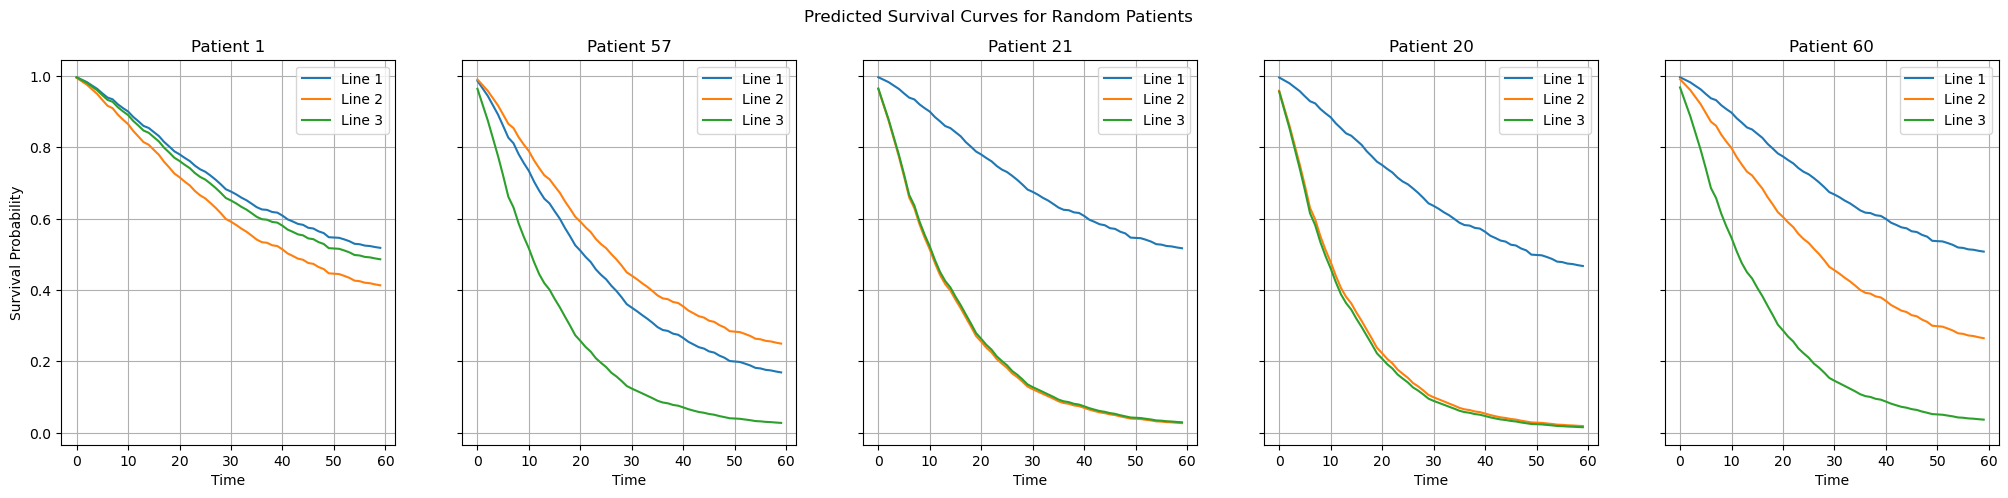

In [58]:
n_samples_to_plot = 5
patient_indices = np.random.choice(batch_prediction.shape[0], size=n_samples_to_plot, replace=False)
patient_prediction = batch_prediction[patient_indices, :, :].cpu()

fig, ax = plt.subplots(ncols=n_samples_to_plot, figsize=(5 * n_samples_to_plot, 5), sharey=True)
for i in range(n_samples_to_plot):
    for time in range(patient_prediction.shape[1]):
        ax[i].plot(patient_prediction[i, time, :].cpu().detach().numpy(), label=f"Line {time + 1}")
    ax[i].set_title(f"Patient {patient_indices[i]}")
    ax[i].set_xlabel("Time")
    if i == 0:
        ax[i].set_ylabel("Survival Probability")
    ax[i].legend()
    ax[i].grid()
fig.suptitle("Predicted Survival Curves for Random Patients")
plt.show()